# Determine Kd for the Monomer-Dimer-Oligomer Model based on species fraction and protein concentrations

**Purpose**
This notebook fits two competing equilibrium models — a 2-state (monomer–dimer) and a 3-state (monomer–dimer–tetramer) model — to raw single-cell species fraction data from MC4R brightness/FLIM measurements. It is the unweighted version, used when data are sparse and per-bin SEM values are not available. Both models are fit simultaneously and compared via AIC/BIC to determine which oligomerization scheme is better supported by the data.

**Input**
Tab-delimited txt-file with the followgn columns: donor_uM, acceptor_uM, f_monomer, f_dimer, f_tetramer

Total concentration is computed on the fly as Ct = donor_uM + acceptor_uM

**Physical Models**
*2-state: Monomer ⇌ Dimer*

M + M ⇌ D, K_D1 = [M]² / [D]

Solved analytically via the quadratic formula:

(2/K_D1) · M² + M − C_t = 0 → M = K_D1/4 · (√(1 + 8C_t/K_D1) − 1)

*3-state: Monomer ⇌ Dimer ⇌ Tetramer*

M + M ⇌ D (K_D1),  D + D ⇌ T (K_D2)

Concentrations:

D = M²/K_D1,  T = M⁴/(K_D1² · K_D2)

Mass balance solved numerically via fsolve:

M + 2D + 4T = C_t

Fractions are by subunit count (i.e., f_D = 2D/total), consistent with the labeling statistics in a FRET/brightness experiment.

**Workflow**
- Cells 1–5 — Prototype (simple fitting, no bootstrap)
- Cell 7 — Full analysis pipeline

Three core functions:
- eq_fractions_3state_from_Ct(Ct, Kd1, Kd2) — Numerically solves mass balance for the 3-state model; returns (f_M, f_D, f_T).
- eq_fractions_2state_from_Ct(Ct, Kd1) — Analytic quadratic solution for the 2-state model; returns (f_M, f_D, 0).
- residuals_3state / residuals_2state — Compute per-point residuals as a flat array for least_squares. A weights argument exists but is passed as None throughout in this notebook — no weighting is applied.
- fit_model_and_bootstrap(data_df, model, ...) — The main fitting engine:

| Step | Details | 
| --- | --- |
| Fitting | least_squares with Trust Region Reflective (trf) method; bounds [1e-8, 1e6] µM for all K_D parameters | 
| Uncertainty (asymptotic) | Standard errors from the Jacobian: SE = √diag((JᵀJ)⁻¹ · s²), where s² = 2·cost/dof | 
| Model selection | AIC and BIC computed from RSS | 
| Bootstrapping | 500 iterations, resampling cells with replacement; 2.5th/97.5th percentile CI | 

- fit_and_compare_both(data_df, output_prefix) — Convenience wrapper that runs both models back-to-back and prints a model comparison table (ΔAIC, ΔBIC).


**Output files**
Per model (2state / 3state), saved with the input filename as prefix:

| File | Contents | 
| --- | --- |
| *_fit_summary.csv* | Fitted K_D values, SE, RSS, AIC, BIC, bootstrap 95% CI | 
| *_fit_results.csv* | Per-cell table with experimental fractions, predicted fractions, and residuals | 
| *_bootstrap_samples.csv* | Raw bootstrap parameter samples (500 × n_params) | 
| *_diagnostics.png | Two-panel plot: fit overlay (log x-axis) + residuals vs. concentration | 

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import fsolve, minimize
import matplotlib.pyplot as plt

In [2]:
# --- Equilibrium function ---
def equilibrium_fractions(Ct, Kd1, Kd2):
    """Compute species fractions for total concentration Ct and Kd1, Kd2."""
    def mass_balance(M):
        return M + 2*(M**2/Kd1) + 4*(M**4/(Kd1**2*Kd2)) - Ct
    M = fsolve(mass_balance, Ct/2, xtol=1e-12)[0]
    D = M**2 / Kd1
    T = M**4 / (Kd1**2 * Kd2)
    total = M + 2*D + 4*T
    return M/total, 2*D/total, 4*T/total

# --- Objective function for fitting ---
def residuals(params, concs, exp_fracs):
    Kd1, Kd2 = params
    if Kd1 <= 0 or Kd2 <= Kd1:
        return 1e6  # enforce positivity
    err = 0.0
    for Ct, fexp in zip(concs, exp_fracs):
        fpred = equilibrium_fractions(Ct, Kd1, Kd2)
        err += np.sum((np.array(fpred) - np.array(fexp))**2)
    return err

In [3]:
# --- Load data ---
# Example structure of your data:
# donor_uM,acceptor_uM,f_monomer,f_dimer,f_tetramer
data = pd.read_csv("./Multi_B2/MC4R-B2_MultiBright.txt", sep='\t')

data.head()

,donor_uM,acceptor_uM,f_monomer,f_dimer,f_tetramer
0,1.311699,1.237852,0.712,0.223488,0.064512
1,0.798095,3.418677,0.570,0.399040,0.030960
2,2.472351,2.493115,0.623,0.354757,0.022394
3,0.690925,1.924666,0.520,0.397920,0.082080
4,1.275361,1.845410,0.760,0.198720,0.041280


In [4]:
# Compute total receptor concentration (donor + acceptor)
data["Ct"] = data["donor_uM"] + data["acceptor_uM"]

concs = data["Ct"].values
exp_fracs = data[["f_monomer","f_dimer","f_tetramer"]].values

# --- Fit ---
initial_guess = [10.0, 100.0]  # initial Kd1, Kd2 in µM
res = minimize(residuals, initial_guess, args=(concs, exp_fracs),
               bounds=[(1e-4, 1e3), (1e-4, 1e3)],
               method='L-BFGS-B')

Kd1_fit, Kd2_fit = res.x
print(f"\nEstimated Kd₁ = {Kd1_fit:.3f} µM")
print(f"Estimated Kd₂ = {Kd2_fit:.3f} µM")

/tmp/ipykernel_1341784/2589066895.py:6: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  M = fsolve(mass_balance, Ct/2, xtol=1e-12)[0]



Estimated Kd₁ = 5.316 µM
Estimated Kd₂ = 10.045 µM


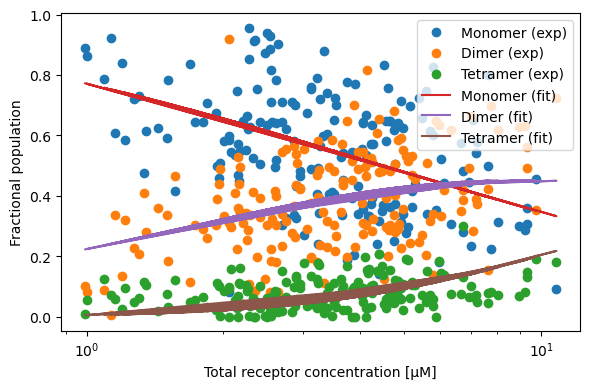

In [5]:
# --- Visualize fit ---
pred_fracs = np.array([equilibrium_fractions(Ct, Kd1_fit, Kd2_fit) for Ct in concs])

plt.figure(figsize=(6,4))
plt.xscale("log")
plt.plot(concs, exp_fracs[:,0], 'o', label="Monomer (exp)")
plt.plot(concs, exp_fracs[:,1], 'o', label="Dimer (exp)")
plt.plot(concs, exp_fracs[:,2], 'o', label="Tetramer (exp)")

plt.plot(concs, pred_fracs[:,0], '-', label="Monomer (fit)")
plt.plot(concs, pred_fracs[:,1], '-', label="Dimer (fit)")
plt.plot(concs, pred_fracs[:,2], '-', label="Tetramer (fit)")

plt.xlabel("Total receptor concentration [µM]")
plt.ylabel("Fractional population")
plt.legend()
plt.tight_layout()
plt.show()

# Comparison Dimer <-> Oligomer Model

In [6]:
# save_as: fit_compare_2v3state.py
import numpy as np
import pandas as pd
from scipy.optimize import least_squares, fsolve
import matplotlib.pyplot as plt
import os

# ---------------------------
# Model math
# ---------------------------

def eq_fractions_3state_from_Ct(Ct, Kd1, Kd2):
    """
    3-state: M + M <-> D   (Kd1)
             2D <-> T     (Kd2)
    Returns fractions (fM, fD, fT) by SUBUNIT count as before.
    """
    def mass_balance(M):
        return M + 2*(M**2 / Kd1) + 4*(M**4 / (Kd1**2 * Kd2)) - Ct
    # robust guess
    M_guess = min(Ct, max(1e-8, Kd1))
    M = fsolve(mass_balance, M_guess, xtol=1e-12, maxfev=5000)[0]
    M = max(M, 0.0)
    D = M**2 / Kd1
    T = M**4 / (Kd1**2 * Kd2)
    total = M + 2*D + 4*T
    if total <= 0:
        return (0.0, 0.0, 0.0)
    return (M/total, 2*D/total, 4*T/total)

def eq_fractions_2state_from_Ct(Ct, Kd1):
    """
    2-state: M + M <-> D   (Kd1)
    Analytic quadratic for M: (2/Kd1) * M^2 + M - Ct = 0
    Solve for non-negative root -> compute D, return proportions (fM, fD, fT=0).
    """
    a = 2.0 / Kd1
    b = 1.0
    c = -Ct
    # solve quadratic: a M^2 + b M + c = 0
    disc = b*b - 4*a*c
    if disc < 0:
        M = 0.0
    else:
        root1 = (-b + np.sqrt(disc)) / (2*a)
        root2 = (-b - np.sqrt(disc)) / (2*a)
        # choose positive root
        M = max(root1, root2, 0.0)
    D = M**2 / Kd1
    total = M + 2*D
    if total <= 0:
        return (0.0, 0.0, 0.0)
    return (M/total, 2*D/total, 0.0)

# ---------------------------
# Residuals wrappers
# ---------------------------
def residuals_3state(params, Ct_array, exp_fracs_array, weights=None):
    Kd1, Kd2 = params
    if Kd1 <= 0 or Kd2 <= 0:
        return 1e8 * np.ones(exp_fracs_array.size)
    res = np.zeros_like(exp_fracs_array)
    for i, Ct in enumerate(Ct_array):
        res[i,:] = np.array(eq_fractions_3state_from_Ct(Ct, Kd1, Kd2)) - exp_fracs_array[i,:]
    if weights is not None:
        res *= weights
    return res.ravel()

def residuals_2state(param, Ct_array, exp_fracs_array, weights=None):
    (Kd1,) = param
    if Kd1 <= 0:
        return 1e8 * np.ones(exp_fracs_array.size)
    res = np.zeros_like(exp_fracs_array)
    for i, Ct in enumerate(Ct_array):
        res[i,:] = np.array(eq_fractions_2state_from_Ct(Ct, Kd1)) - exp_fracs_array[i,:]
    if weights is not None:
        res *= weights
    return res.ravel()

# ---------------------------
# Fit + uncertainty + save
# ---------------------------
def fit_model_and_bootstrap(data_df, model='3state',
                            initial_guess=None, bounds=None,
                            weights_cols=None, do_bootstrap=True,
                            n_bootstrap=500, random_seed=0,
                            output_prefix='fit_output'):
    """
    model: '3state' or '2state'
    initial_guess: tuple
    bounds: (lower, upper) matching least_squares shape
    weights_cols: tuple names for SD columns (sd_mono, sd_dimer, sd_tet)
    """
    Ct = (data_df['donor_uM'] + data_df['acceptor_uM']).values
    exp_fracs = data_df[['f_monomer','f_dimer','f_tetramer']].values

    # optional weights
    weights = None
    if weights_cols is not None:
        sd = data_df[list(weights_cols)].values.astype(float)
        sd[sd <= 0] = np.nan
        if np.isnan(sd).any():
            print("Warning: invalid SDs; ignoring weights.")
            weights = None
        else:
            weights = 1.0 / sd

    # choose residual function and initial/bounds if not provided
    if model == '3state':
        if initial_guess is None:
            initial_guess = np.array([20.0, 1000.0])
        if bounds is None:
            bounds = ([1e-8, 1e-8],[1e6, 1e6])
        res = least_squares(residuals_3state, x0=np.array(initial_guess),
                            args=(Ct, exp_fracs, weights), bounds=bounds,
                            method='trf', xtol=1e-12, ftol=1e-12, gtol=1e-12, max_nfev=5000)
        params_fit = res.x
        # asymptotic covariance
        J = res.jac; m = J.shape[0]; p = len(params_fit); dof = max(1, m - p)
        s_sq = 2.0 * res.cost / dof
        try:
            cov = np.linalg.inv(J.T @ J) * s_sq
            se = np.sqrt(np.diag(cov))
        except np.linalg.LinAlgError:
            cov = np.full((p,p), np.nan); se = np.full(p, np.nan)
    else:
        # 2-state
        if initial_guess is None:
            initial_guess = np.array([1.0])
        if bounds is None:
            bounds = ([1e-8],[1e6])
        res = least_squares(residuals_2state, x0=np.array(initial_guess),
                            args=(Ct, exp_fracs, weights), bounds=bounds,
                            method='trf', xtol=1e-12, ftol=1e-12, gtol=1e-12, max_nfev=5000)
        params_fit = res.x
        J = res.jac; m = J.shape[0]; p = len(params_fit); dof = max(1, m - p)
        s_sq = 2.0 * res.cost / dof
        try:
            cov = np.linalg.inv(J.T @ J) * s_sq
            se = np.sqrt(np.diag(cov))
        except np.linalg.LinAlgError:
            cov = np.full((p,p), np.nan); se = np.full(p, np.nan)

    # predictions and residuals
    if model == '3state':
        preds = np.array([eq_fractions_3state_from_Ct(c, params_fit[0], params_fit[1]) for c in Ct])
    else:
        preds = np.array([eq_fractions_2state_from_Ct(c, params_fit[0]) for c in Ct])
    resid = exp_fracs - preds
    RSS = np.sum((resid)**2)
    m_points = exp_fracs.size  # number of data points (3 * N)
    p_params = len(params_fit)
    # AIC and BIC (using ordinary-least-squares likelihood approx)
    AIC = m_points * np.log(RSS / m_points + 1e-20) + 2 * p_params
    BIC = m_points * np.log(RSS / m_points + 1e-20) + p_params * np.log(m_points)

    # bootstrap
    bs_samples = None
    bs_ci = None
    if do_bootstrap:
        rng = np.random.default_rng(random_seed)
        samples = []
        for b in range(n_bootstrap):
            idx = rng.integers(0, len(Ct), len(Ct))
            Ct_b = Ct[idx]; exp_b = exp_fracs[idx]
            try:
                if model == '3state':
                    rb = least_squares(residuals_3state, x0=params_fit,
                                       args=(Ct_b, exp_b, None),
                                       bounds=bounds, method='trf',
                                       xtol=1e-9, ftol=1e-9, max_nfev=3000)
                    samples.append(rb.x)
                else:
                    rb = least_squares(residuals_2state, x0=params_fit,
                                       args=(Ct_b, exp_b, None),
                                       bounds=bounds, method='trf',
                                       xtol=1e-9, ftol=1e-9, max_nfev=3000)
                    samples.append(rb.x)
            except Exception:
                continue
        if len(samples) > 0:
            bs_samples = np.array(samples)
            # percentile CIs
            ci_low = np.percentile(bs_samples, 2.5, axis=0)
            ci_high = np.percentile(bs_samples, 97.5, axis=0)
            bs_ci = np.vstack((ci_low, ci_high)).T  # rows correspond to parameters
        else:
            bs_samples = None
            bs_ci = None

    # Save results
    base = os.path.splitext(output_prefix)[0]
    model_tag = '3state' if model=='3state' else '2state'
    summary = {
        'model': model_tag,
        'params': params_fit.tolist(),
        'se': se.tolist(),
        'RSS': RSS,
        'AIC': AIC,
        'BIC': BIC,
        'm_points': m_points,
        'p_params': p_params
    }
    if bs_ci is not None:
        for i in range(bs_ci.shape[0]):
            summary[f'param{i+1}_bs_lo'] = bs_ci[i,0]
            summary[f'param{i+1}_bs_hi'] = bs_ci[i,1]

    df_summary = pd.DataFrame([summary])
    df_results = data_df.copy()
    df_results[[f'pred_mono_{model_tag}', f'pred_dim_{model_tag}', f'pred_tet_{model_tag}']] = preds
    df_results[[f'res_mono_{model_tag}', f'res_dim_{model_tag}', f'res_tet_{model_tag}']] = resid

    summary_fname = f"{base}_{model_tag}_fit_summary.csv"
    results_fname = f"{base}_{model_tag}_fit_results.csv"
    df_summary.to_csv(summary_fname, index=False)
    df_results.to_csv(results_fname, index=False)
    if bs_samples is not None:
        np.savetxt(f"{base}_{model_tag}_bootstrap_samples.csv", bs_samples, delimiter=',',
                   header=','.join([f'param{i+1}' for i in range(bs_samples.shape[1])]))
    # diagnostic plots
    plot_fname = f"{base}_{model_tag}_diagnostics.png"
    fig, axes = plt.subplots(2,1, figsize=(7,8))
    Ct_sorted_idx = np.argsort(Ct)
    Ct_s = Ct[Ct_sorted_idx]
    exp_s = exp_fracs[Ct_sorted_idx]
    pred_s = preds[Ct_sorted_idx]
    axes[0].set_xscale('log')
    axes[0].plot(Ct_s, exp_s[:,0], 'o', label='Mono (exp)')
    axes[0].plot(Ct_s, exp_s[:,1], 'o', label='Dimer (exp)')
    axes[0].plot(Ct_s, exp_s[:,2], 'o', label='Tet (exp)')
    axes[0].plot(Ct_s, pred_s[:,0], '-', label='Mono (pred)')
    axes[0].plot(Ct_s, pred_s[:,1], '-', label='Dimer (pred)')
    axes[0].plot(Ct_s, pred_s[:,2], '-', label='Tet (pred)')
    axes[0].set_ylabel('Fractions'); axes[0].legend()
    axes[1].plot(Ct_s, (exp_s - pred_s)[:,0], 'o-', label='res mono')
    axes[1].plot(Ct_s, (exp_s - pred_s)[:,1], 'o-', label='res dimer')
    axes[1].plot(Ct_s, (exp_s - pred_s)[:,2], 'o-', label='res tet')
    axes[1].axhline(0, color='k', lw=0.6)
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Total concentration (µM)')
    axes[1].set_ylabel('Residuals (exp - pred)')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(plot_fname, dpi=200)
    plt.close(fig)

    print(f"Saved: {summary_fname}, {results_fname}, {plot_fname}")
    if bs_samples is not None:
        print(f"Saved bootstrap samples to {base}_{model_tag}_bootstrap_samples.csv")

    return df_summary, df_results, bs_samples

# ---------------------------
# Convenience wrapper: run both models and compare
# ---------------------------
def fit_and_compare_both(data_df, output_prefix, **kwargs):
    # Fit 2-state
    sum2, res2, bs2 = fit_model_and_bootstrap(data_df, model='2state',
                                              initial_guess=(1.0,),
                                              bounds=([1e-8],[1e6]),
                                              output_prefix=output_prefix, **kwargs)
    # Fit 3-state
    sum3, res3, bs3 = fit_model_and_bootstrap(data_df, model='3state',
                                              initial_guess=(1.0,10.0),
                                              bounds=([1e-8,1e-8],[1e6,1e6]),
                                              output_prefix=output_prefix, **kwargs)

    # Compare AIC/BIC
    aic2 = sum2['AIC'].iloc[0]; bic2 = sum2['BIC'].iloc[0]; rss2 = sum2['RSS'].iloc[0]
    aic3 = sum3['AIC'].iloc[0]; bic3 = sum3['BIC'].iloc[0]; rss3 = sum3['RSS'].iloc[0]
    print("\n=== Model comparison ===")
    print(f"2-state: RSS={rss2:.4g}, AIC={aic2:.3f}, BIC={bic2:.3f}")
    print(f"3-state: RSS={rss3:.4g}, AIC={aic3:.3f}, BIC={bic3:.3f}")
    daic = aic2 - aic3
    dbic = bic2 - bic3
    print(f"ΔAIC (2 - 3) = {daic:.3f}  (positive -> 3-state favored)")
    print(f"ΔBIC (2 - 3) = {dbic:.3f}  (positive -> 3-state favored)")

    return {'2state': (sum2, res2, bs2), '3state': (sum3, res3, bs3)}



In [7]:
# Replace with your filename
infile = "./Multi_B2/MC4R-B2_MultiBright.txt"
if not os.path.exists(infile):
    raise FileNotFoundError(f"Place your data TXT named '{infile}' in this folder and re-run.")
data = pd.read_csv(infile, sep='\t')

# Run fits (adjust bootstrap and weights as desired)
results = fit_and_compare_both(data, output_prefix=os.path.splitext(infile)[0],
                                weights_cols=None,
                                do_bootstrap=True, n_bootstrap=500, random_seed=123)

# prints summary files saved and comparison summary

Saved: ./Multi_B2/MC4R-B2_MultiBright_2state_fit_summary.csv, ./Multi_B2/MC4R-B2_MultiBright_2state_fit_results.csv, ./Multi_B2/MC4R-B2_MultiBright_2state_diagnostics.png
Saved bootstrap samples to ./Multi_B2/MC4R-B2_MultiBright_2state_bootstrap_samples.csv


/tmp/ipykernel_1341784/2982414808.py:22: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  M = fsolve(mass_balance, M_guess, xtol=1e-12, maxfev=5000)[0]


Saved: ./Multi_B2/MC4R-B2_MultiBright_3state_fit_summary.csv, ./Multi_B2/MC4R-B2_MultiBright_3state_fit_results.csv, ./Multi_B2/MC4R-B2_MultiBright_3state_diagnostics.png
Saved bootstrap samples to ./Multi_B2/MC4R-B2_MultiBright_3state_bootstrap_samples.csv

=== Model comparison ===
2-state: RSS=12.25, AIC=-2099.819, BIC=-2095.505
3-state: RSS=10.74, AIC=-2170.609, BIC=-2161.982
ΔAIC (2 - 3) = 70.790  (positive -> 3-state favored)
ΔBIC (2 - 3) = 66.477  (positive -> 3-state favored)


## Quick notes and recommended workflow

Use the 2-state fit to check whether Kd2 is effectively unconstrained. If the 3-state fit returns Kd2 ≫ highest measured Ct and bootstrap shows wide CI including very large values, the 2-state model may be adequate.

Interpretation of AIC/BIC:

- Small ΔAIC (|Δ| < 2) → both models roughly equivalent.

- ΔAIC between 4–7 → moderate evidence; >10 → strong evidence favoring the model with lower AIC.

- BIC penalizes model complexity more strongly; use if you want stronger parsimony.
